# Covertype + TabFM + XAI
**Before running:** Runtime → Change runtime type → **T4 GPU**. Then Runtime → Run all.

## 1. Install

In [ ]:
!git clone -q --depth 1 https://github.com/google-research/tabfm.git
!pip install -q "./tabfm[pytorch]" lime
!wget -q https://archive.ics.uci.edu/static/public/31/covertype.zip && unzip -o -q covertype.zip

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


## 2. The dataset
Each row is a 30m × 30m patch of forest in Colorado.
**Objective:** predict which of 7 tree types grows there (classification), using map data such as elevation, slope and distance to water.

In [ ]:
import pandas as pd

columns = (["Elevation", "Aspect", "Slope", "Horiz_Dist_Hydrology", "Vert_Dist_Hydrology",
            "Horiz_Dist_Roadways", "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
            "Horiz_Dist_Fire_Points"]
           + [f"Wilderness_{i}" for i in range(1, 5)]
           + [f"Soil_{i}" for i in range(1, 41)]
           + ["Cover_Type"])
df = pd.read_csv("covtype.data.gz", header=None, names=columns)

tree_names = {1: "Spruce/Fir", 2: "Lodgepole Pine", 3: "Ponderosa Pine", 4: "Cottonwood/Willow",
              5: "Aspen", 6: "Douglas-fir", 7: "Krummholz"}
df["Cover_Type"] = df["Cover_Type"].map(tree_names)

print(df.shape)
print(df["Cover_Type"].value_counts())
df.head()

(581012, 55)
Cover_Type
Lodgepole Pine       283301
Spruce/Fir           211840
Ponderosa Pine        35754
Krummholz             20510
Douglas-fir           17367
Aspen                  9493
Cottonwood/Willow      2747
Name: count, dtype: int64


,Elevation,Aspect,Slope,Horiz_Dist_Hydrology,Vert_Dist_Hydrology,Horiz_Dist_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horiz_Dist_Fire_Points,...,Soil_32,Soil_33,Soil_34,Soil_35,Soil_36,Soil_37,Soil_38,Soil_39,Soil_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,Aspen
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,Aspen
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,Lodgepole Pine
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,Lodgepole Pine
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,Aspen


## 3. Train TabFM and check performance
The full dataset is 581k rows, which is too big for TabFM, so we take a 4,000-row sample: 3,000 to train on and 1,000 to test on.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

sample = df.sample(4000, random_state=42)
X = sample.drop(columns="Cover_Type")
y = sample["Cover_Type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1000, stratify=y, random_state=42)

In [ ]:
import torch
from tabfm import TabFMClassifier
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1

tabfm_model = tabfm_v1.load(device="cuda", dtype=torch.float32)   # downloads ~6.5 GB the first time
model = TabFMClassifier(model=tabfm_model, n_estimators=8, cache_context=True)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

config.json:   0%|          | 0.00/97.0 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights from local directory
Accuracy: 0.827
                   precision    recall  f1-score   support

            Aspen       0.82      0.53      0.64        17
Cottonwood/Willow       0.00      0.00      0.00         4
      Douglas-fir       0.62      0.62      0.62        29
        Krummholz       0.90      0.77      0.83        35
   Lodgepole Pine       0.84      0.85      0.85       480
   Ponderosa Pine       0.81      0.89      0.85        64
       Spruce/Fir       0.82      0.83      0.83       371

         accuracy                           0.83      1000
        macro avg       0.69      0.64      0.66      1000
     weighted avg       0.82      0.83      0.82      1000



## 4. XAI 1: Permutation feature importance (global)
Shuffle one feature at a time and see how much accuracy drops. A bigger drop means the model relies on that feature more.

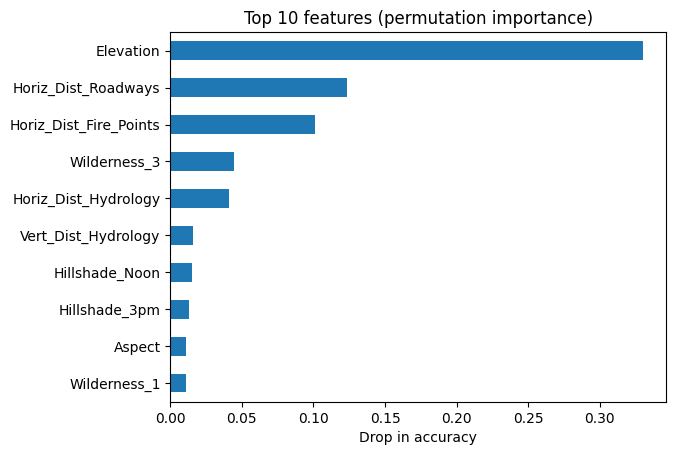

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(model, X_test[:500], y_test[:500], n_repeats=3, random_state=42)
importance = pd.Series(result.importances_mean, index=X.columns).sort_values()

importance.tail(10).plot.barh(title="Top 10 features (permutation importance)")
plt.xlabel("Drop in accuracy")
plt.show()

## 5. XAI 2: LIME (local)
Explain why the model made its prediction for one specific patch of forest.

Actual: Spruce/Fir | Predicted: Spruce/Fir


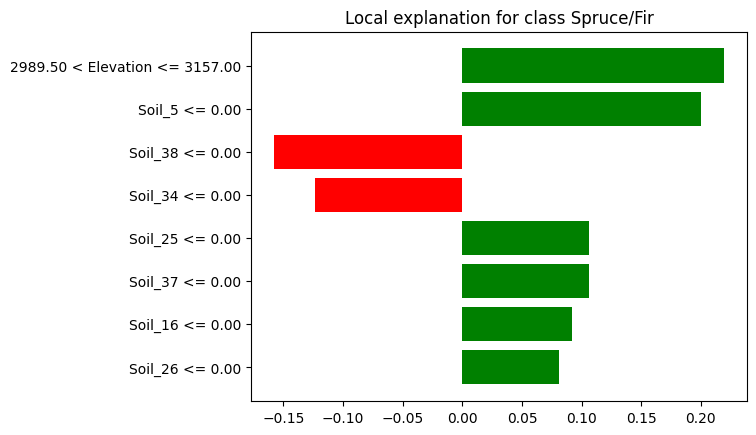

In [7]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import torch

torch.cuda.empty_cache()   # clear out the memory left over from the failed run

explainer = LimeTabularExplainer(X_train.values, feature_names=list(X.columns),
                                 class_names=list(model.classes_), mode="classification")

def predict_fn(rows):
    # send the rows to TabFM 250 at a time so the GPU doesn't run out of memory
    results = []
    for i in range(0, len(rows), 250):
        batch = pd.DataFrame(rows[i:i + 250], columns=X.columns)
        results.append(model.predict_proba(batch))
    return np.vstack(results)

row = X_test.iloc[0]
print("Actual:", y_test.iloc[0], "| Predicted:", model.predict(X_test.iloc[[0]])[0])

explanation = explainer.explain_instance(row.values, predict_fn, num_features=8,
                                         top_labels=1, num_samples=1000)
explanation.as_pyplot_figure(label=explanation.top_labels[0])
plt.show()